<a href="https://colab.research.google.com/github/ericsheng495/chronicling-america-qa-lora/blob/main/phi35_chronicling_america_qa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChroniclingAmericaQA — Phi-3.5 Zero-Shot Baseline

**Dataset:** [Bhawna/ChroniclingAmericaQA](https://huggingface.co/datasets/Bhawna/ChroniclingAmericaQA)  
**Model:** `microsoft/phi-3.5-mini-instruct`  
**Method:** Zero-shot instruction prompting → baseline metrics for QLoRA fine-tuning

This notebook covers:
1. Setup and imports
2. Configuration
3. Load dataset
4. Exploratory data inspection
5. Preprocessing (whitespace normalization, truncation, OCR toggle)
6. Prompt formatting (Phi-3.5 chat template)
7. Zero-shot baseline inference
8. Baseline evaluation (EM, Token F1, ROUGE-L)

---
## 1. Setup and Imports

In [18]:
# Uncomment and run once to install / pin dependencies
!pip install "transformers==4.44.2" datasets peft trl bitsandbytes accelerate
!pip install evaluate rouge_score sentencepiece
!pip install pandas numpy tqdm matplotlib

In [ ]:
import os
import re
import sys
import json
import string
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from datasets import load_dataset
from transformers import set_seed
import evaluate as hf_evaluate

warnings.filterwarnings("ignore")
print("Imports OK.")

Imports OK.


---
## 2. Configuration

All hyperparameters live here. Adjust before running any downstream cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Dataset ─────────────────────────────────────────────────────────────────
DATASET_NAME = "Bhawna/ChroniclingAmericaQA"

MAX_TRAIN_SAMPLES = 500    # None = full split
MAX_DEV_SAMPLES   = 100
MAX_TEST_SAMPLES  = 200

USE_RAW_OCR = False        # True = use raw OCR instead of cleaned context

# ── Sequence lengths ─────────────────────────────────────────────────────────
MAX_INPUT_LENGTH  = 1024   # approximate token budget for context + prompt
MAX_TARGET_LENGTH = 64     # max answer length in tokens

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_NAME          = "microsoft/phi-3.5-mini-instruct"
BASELINE_BATCH_SIZE = 4    # reduce if OOM
GEN_MAX_NEW_TOKENS  = 64
GEN_DO_SAMPLE       = False  # greedy decoding for reproducibility

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED       = 42
OUTPUT_DIR = Path("/content/drive/MyDrive/chronicling_qa")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
print("Configuration loaded.")
print(f"  Dataset    : {DATASET_NAME}")
print(f"  Model      : {MODEL_NAME}")
print(f"  USE_RAW_OCR: {USE_RAW_OCR}")
print(f"  Output dir : {OUTPUT_DIR.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuration loaded.
  Dataset    : Bhawna/ChroniclingAmericaQA
  Model      : microsoft/phi-3.5-mini-instruct
  USE_RAW_OCR: False
  Output dir : /content/drive/MyDrive/chronicling_qa


---
## 3. Load Dataset

Load ChroniclingAmericaQA from the Hugging Face Hub and define field name constants.

In [ ]:
# from huggingface_hub import login; login(token="hf_YOUR_TOKEN_HERE")

print(f"Loading dataset: {DATASET_NAME} ...")
raw_datasets = load_dataset(DATASET_NAME)

train_ds = raw_datasets["train"]
dev_ds   = raw_datasets["validation"]
test_ds  = raw_datasets["test"]

# Field name constants
FIELD_QUESTION = "question"
FIELD_ANSWER   = "answer"
FIELD_CONTEXT  = "context"   # cleaned / gold context
FIELD_RAW_OCR  = "raw_ocr"   # raw OCR text
HAS_RAW_OCR    = FIELD_RAW_OCR in train_ds.column_names

print(f"\nSplits  — Train: {len(train_ds):,}  Dev: {len(dev_ds):,}  Test: {len(test_ds):,}")
print(f"Columns : {train_ds.column_names}")
print(f"HAS_RAW_OCR: {HAS_RAW_OCR}")

Loading dataset: Bhawna/ChroniclingAmericaQA ...

Splits  — Train: 439,302  Dev: 24,111  Test: 24,084
Columns : ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url']
HAS_RAW_OCR: True


---
## 4. Exploratory Data Inspection

Understand the data schema, typical answer lengths, and OCR noise.

In [ ]:
for i, example in enumerate(train_ds.select(range(3))):
    print(f"{'='*70}")
    print(f"Example {i+1}")
    print(f"{'='*70}")
    print(f"QUESTION : {example['question']}")
    print(f"ANSWER   : {example['answer']}")
    print(f"CONTEXT  : {example['context'][:300]}...")
    if HAS_RAW_OCR:
        print(f"RAW OCR  : {example['raw_ocr'][:300]}...")
    print()

Example 1
QUESTION : Who is the author of the book, "Horrors of Slavery, or the American Turf in Tripoli"?
ANSWER   : WILLIAM RAY
CONTEXT  : Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. BY: WILLIAM RAY, Author of the contemplated publication, entitled, “Horrors of Slavery, or the American Turf in Tripoli,” VOTARIES of Freedom, arm! The British Lion roars! Legions ...
RAW OCR  : fAiscellancous Bepogitory.
. dvom the Albany Regifier,
. . WAR,OR A PROSPECT OF IT,
From recent inflances of Britifp Oulrage.
 BY: WILLIAM RAY:
HAuthsr of the tontemplated publication, entitled,
« Horrors of Slavery,or the American Turg
in Tripoli,”
VOT’RIES of Freedom, arm!
 The British Lion roars ...

Example 2
QUESTION : Who was the Grand Officer of the Legion of Honor?
ANSWER   : de Rosemberg
CONTEXT  : Surely he above the rest of his fellow mortals, partakes of heaven here below, of bliss which none but the virtuous ever claim. ¥ Obi

In [27]:
def compute_length_stats(dataset, field, label):
    lengths = [len(str(ex.get(field, "")).split()) for ex in dataset]
    return {
        "field": label,
        "mean":   round(float(np.mean(lengths)), 1),
        "median": round(float(np.median(lengths)), 1),
        "p95":    round(float(np.percentile(lengths, 95)), 1),
        "max":    int(np.max(lengths)),
    }

stats_rows = [
    compute_length_stats(train_ds, FIELD_QUESTION, "Question"),
    compute_length_stats(train_ds, FIELD_ANSWER,   "Answer"),
    compute_length_stats(train_ds, FIELD_CONTEXT,  "Context (clean)"),
]
if HAS_RAW_OCR:
    stats_rows.append(compute_length_stats(train_ds, FIELD_RAW_OCR, "Context (OCR)"))

stats_df = pd.DataFrame(stats_rows).set_index("field")
print("Word-count statistics (train split):")
display(stats_df)

Word-count statistics (train split):


,mean,median,p95,max
field,,,,
Question,11.1,10.0,18.0,30
Answer,2.0,2.0,4.0,47
Context (clean),219.7,225.0,245.0,4077
Context (OCR),233.9,240.0,250.0,1115


---
## 5. Preprocessing

Minimal, reversible preprocessing: choose OCR vs. clean context, normalize
whitespace, handle missing values, and truncate long passages.

In [ ]:
CONTEXT_MAX_WORDS = int(MAX_INPUT_LENGTH * 0.6)


def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def get_context(example: dict, use_raw_ocr: bool = False) -> str:
    field = FIELD_RAW_OCR if (use_raw_ocr and HAS_RAW_OCR) else FIELD_CONTEXT
    return normalize_whitespace(str(example.get(field, "") or ""))


def preprocess_example(example: dict) -> dict:
    question = normalize_whitespace(str(example.get(FIELD_QUESTION, "") or ""))
    answer   = normalize_whitespace(str(example.get(FIELD_ANSWER,   "") or ""))
    context  = get_context(example, use_raw_ocr=USE_RAW_OCR)
    context  = " ".join(context.split()[:CONTEXT_MAX_WORDS])
    return {"question": question, "answer": answer, "context": context}


print("Applying preprocessing ...")
train_clean = train_ds.map(preprocess_example, desc="Preprocess train")
dev_clean   = dev_ds.map(preprocess_example,   desc="Preprocess dev")
test_clean  = test_ds.map(preprocess_example,  desc="Preprocess test")

ex = train_clean[0]
assert ex["question"], "Question should not be empty after preprocessing"
print(f"\nSample:")
print(f"  Q: {ex['question']}")
print(f"  A: {ex['answer']}")
print(f"  Context ({len(ex['context'].split())} words): {ex['context'][:200]}...")

Applying preprocessing ...

Sample:
  Q: Who is the author of the book, "Horrors of Slavery, or the American Turf in Tripoli"?
  A: WILLIAM RAY
  Context (196 words): Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. BY: WILLIAM RAY, Author of the contemplated publication, entitled, “Horrors of S...


---
## 6. Prompt Formatting

Instruction-style prompt compatible with Phi-3.5's chat template.
The same helpers are shared between inference and training.

In [ ]:
SYSTEM_PROMPT = (
    "You are answering questions about historical American newspapers. "
    "Use the provided context to answer the question briefly and accurately. "
    'If the answer is not supported by the context, say "Not enough information.".'
)


def format_prompt_for_inference(context: str, question: str) -> str:
    user_msg = f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"
    return (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{user_msg}<|end|>\n"
        "<|assistant|>\n"
    )


def format_prompt_for_training(context: str, question: str, answer: str) -> str:
    return format_prompt_for_inference(context, question) + answer + "<|end|>"


# Sanity check
sample = train_clean[0]
print("=== Inference prompt (first 500 chars) ===")
print(format_prompt_for_inference(sample["context"], sample["question"])[:500])
print("\n=== Training sequence tail ===")
full = format_prompt_for_training(sample["context"], sample["question"], sample["answer"])
print(full[-80:])

=== Inference prompt (first 500 chars) ===
<|system|>
You are answering questions about historical American newspapers. Use the provided context to answer the question briefly and accurately. If the answer is not supported by the context, say "Not enough information.".<|end|>
<|user|>
Context:
Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. BY: WILLIAM RAY, Author of the contemplated publication, entitled, “Horrors of Slavery, or the American Turf in Tripoli,” VOTARI

=== Training sequence tail ===
 the American Turf in Tripoli"?

Answer:<|end|>
<|assistant|>
WILLIAM RAY<|end|>


---
## 7. Zero-Shot Baseline Inference

Load `microsoft/phi-3.5-mini-instruct` without fine-tuning and run greedy
generation on the dev subset to establish a pre-training baseline.

> **Note:** requires `transformers==4.44.2` — the model's bundled
> `modeling_phi3.py` uses `DynamicCache.from_legacy_cache` which was removed
> in later versions. The cell below flushes any cached newer version.

In [ ]:
# Ensure transformers 4.44.2 is active (compatible with phi-3.5 custom modeling)
import importlib
for mod in [k for k in sys.modules if k.startswith("transformers")]:
    del sys.modules[mod]

from transformers import AutoTokenizer, AutoModelForCausalLM
import transformers
print(f"transformers: {transformers.__version__}  |  CUDA: {torch.cuda.is_available()}")

baseline_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
baseline_tokenizer.pad_token    = baseline_tokenizer.eos_token
baseline_tokenizer.padding_side = "left"   # required for left-padded batch generation

baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
baseline_model.eval()
print(f"Model on : {next(baseline_model.parameters()).device}")
print(f"Params   : {sum(p.numel() for p in baseline_model.parameters()):,}")

transformers: 4.44.2  |  CUDA: False


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model on : cpu
Params   : 3,821,079,552


In [ ]:
import shutil
from pathlib import Path
import pandas as pd

def generate_answers_batch(examples, tokenizer, model, batch_size=BASELINE_BATCH_SIZE):
    """Batched greedy generation; returns one answer string per example."""
    _end_id = tokenizer.convert_tokens_to_ids("<|end|>")
    _eos    = list({tokenizer.eos_token_id, _end_id})

    all_preds = []
    n = len(examples)
    for start in tqdm(range(0, n, batch_size), desc="Inference"):
        # Use .select() — Dataset[a:b] returns dict-of-lists, not list-of-dicts
        batch   = examples.select(range(start, min(start + batch_size, n)))
        prompts = [
            format_prompt_for_inference(batch[i]["context"], batch[i]["question"])
            for i in range(len(batch))
        ]
        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LENGTH,
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                do_sample=GEN_DO_SAMPLE,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=_eos,
            )

        for out in output_ids:
            decoded = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            all_preds.append(decoded.strip().split("\n")[0].strip())

    return all_preds


# ── Run inference & Caching ──────────────────────────────────────────────────
baseline_csv = OUTPUT_DIR / "dev_predictions_baseline.csv"
local_baseline_csv = Path("/content/outputs/chronicling_qa/dev_predictions_baseline.csv")

# Migrate old local file to Drive if it exists
if local_baseline_csv.exists() and not baseline_csv.exists():
    print(f"Migrating local predictions to Drive: {baseline_csv}")
    shutil.copy(local_baseline_csv, baseline_csv)

if baseline_csv.exists():
    print(f"Loading cached baseline predictions from {baseline_csv} ...")
    baseline_df = pd.read_csv(baseline_csv)
    baseline_preds = baseline_df["prediction"].tolist()
    baseline_golds = baseline_df["gold_answer"].tolist()
    baseline_questions = baseline_df["question"].tolist()
else:
    print("No cache found. Running inference...")
    dev_eval           = dev_clean.select(range(min(MAX_DEV_SAMPLES, len(dev_clean))))
    baseline_preds     = generate_answers_batch(dev_eval, baseline_tokenizer, baseline_model)
    baseline_golds     = [dev_eval[i]["answer"]   for i in range(len(dev_eval))]
    baseline_questions = [dev_eval[i]["question"] for i in range(len(dev_eval))]

    # ── Save to CSV ───────────────────────────────────────────────────────────
    baseline_df  = pd.DataFrame({
        "question":    baseline_questions,
        "gold_answer": baseline_golds,
        "prediction":  baseline_preds,
    })
    baseline_df.to_csv(baseline_csv, index=False)
    print(f"Saved {len(baseline_df)} predictions → {baseline_csv}")

print(f"\nFirst 5 predictions vs. gold:")
for q, pred, gold in zip(baseline_questions[:5], baseline_preds[:5], baseline_golds[:5]):
    print(f"  Q   : {q}")
    print(f"  Pred: {pred}")
    print(f"  Gold: {gold}\n")

Loading cached baseline predictions from /content/drive/MyDrive/chronicling_qa/dev_predictions_baseline.csv ...

First 5 predictions vs. gold:
  Q   : How much of the crew would Gerry want to shore up in a gale of wind?
  Pred: Half of the crew
  Gold: half

  Q   : How many Irish Linens are low-priced?
  Pred: 30 Dozen Irish Linens are low-priced.
  Gold: 300 Dozen

  Q   : How long does it take for the heirs of the said Israel to appear before the Judge?
  Pred: The context does not provide a specific time frame for the heirs to appear before the Judge. It only states that they are to appear on the 15th day of June. Therefore, there is not enough information to determine the exact time it takes for them to appear.
  Gold: three weeks

  Q   : Whose Store did JOHN DORRANCE receive the Reports of the Case?
  Pred: W.R. Wilpre's Store
  Gold: Allspice

  Q   : How many Delaware counties are in the Gazette of the United States?
  Pred: Not enough information. The context does not specify

---
## 8. Baseline Evaluation

Compute **Exact Match (EM)**, **Token F1** (SQuAD-style), and **ROUGE-L**
for the zero-shot baseline predictions.

In [ ]:
# ── Normalization (SQuAD-style) ──────────────────────────────────────────────

def normalize_answer(s: str) -> str:
    """Lowercase, strip punctuation, remove articles, collapse whitespace."""
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return " ".join(s.split())


def get_tokens(s: str) -> list:
    return normalize_answer(s).split()


# ── Exact Match ───────────────────────────────────────────────────────────────

def exact_match(prediction: str, gold: str) -> int:
    return int(normalize_answer(prediction) == normalize_answer(gold))


# ── Token F1 ──────────────────────────────────────────────────────────────────

def token_f1(prediction: str, gold: str) -> float:
    pred_tokens = get_tokens(prediction)
    gold_tokens = get_tokens(gold)
    common   = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


# ── ROUGE-L ───────────────────────────────────────────────────────────────────

rouge_metric = hf_evaluate.load("rouge")

def compute_rouge_l(predictions: list, references: list) -> float:
    return rouge_metric.compute(
        predictions=predictions,
        references=references,
        rouge_types=["rougeL"],
        use_stemmer=True,
    )["rougeL"]


# ── Aggregate ─────────────────────────────────────────────────────────────────

def compute_metrics(predictions: list, references: list, label: str = "") -> dict:
    em_scores = [exact_match(p, g) for p, g in zip(predictions, references)]
    f1_scores = [token_f1(p, g)    for p, g in zip(predictions, references)]
    return {
        "split":   label,
        "n":       len(predictions),
        "EM":      round(100 * sum(em_scores) / len(em_scores), 2),
        "F1":      round(100 * sum(f1_scores) / len(f1_scores), 2),
        "ROUGE-L": round(100 * compute_rouge_l(predictions, references), 2),
    }


# ── Results ───────────────────────────────────────────────────────────────────

baseline_metrics = compute_metrics(
    baseline_preds, baseline_golds, label="baseline (zero-shot)"
)

print("=" * 50)
print(f"  Baseline Zero-Shot  (n={baseline_metrics['n']})")
print("=" * 50)
print(f"  Exact Match : {baseline_metrics['EM']:.2f}%")
print(f"  Token F1    : {baseline_metrics['F1']:.2f}%")
print(f"  ROUGE-L     : {baseline_metrics['ROUGE-L']:.2f}%")
print("=" * 50)

  Baseline Zero-Shot  (n=100)
  Exact Match : 13.00%
  Token F1    : 31.34%
  ROUGE-L     : 32.44%


---
## Section 9 — Training Configuration

All training hyperparameters live here. `TRAINING_MODE` switches between
LoRA and full fine-tuning. LoRA uses `phi-3.5-mini-instruct` in **fp16**
(no 4-bit quantisation so results are unconfounded). Full fine-tuning uses
`phi-2` (2.7 B) for compute feasibility.

In [ ]:
from pathlib import Path
import torch
from transformers import set_seed

# ── Models ────────────────────────────────────────────────────────────────────
MODEL_NAME_LORA    = "microsoft/phi-3.5-mini-instruct"

# ── Sample limits ─────────────────────────────────────────────────────────────
MAX_TRAIN_SAMPLES_FT = 500       # set None for full dataset (very slow)
MAX_DEV_SAMPLES_FT   = 100
MAX_TEST_SAMPLES_FT  = 200

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE        = 2
GRAD_ACCUM_STEPS  = 8            # effective batch size = 16
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-4
MAX_SEQ_LEN       = 768          # max tokens for training sequences

# ── LoRA ──────────────────────────────────────────────────────────────────────
LORA_RANK         = 16
LORA_ALPHA        = 32
LORA_DROPOUT      = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "v_proj", "k_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

LORA_RANKS = [8, 16, 32, 64]    # rank ablation sweep

# ── Paths ─────────────────────────────────────────────────────────────────────
FT_OUTPUT_DIR = Path("/content/drive/MyDrive/chronicling_qa/fine_tuned")
FT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Precision ─────────────────────────────────────────────────────────────────
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

set_seed(SEED)   # SEED defined in original config cell

print(f"DEVICE        : {DEVICE}")
print(f"precision     : {'bf16' if USE_BF16 else 'fp16' if USE_FP16 else 'fp32'}")
print(f"LORA_RANK     : {LORA_RANK}")
print(f"NUM_EPOCHS    : {NUM_EPOCHS}")
print(f"FT_OUTPUT_DIR : {FT_OUTPUT_DIR.resolve()}")

DEVICE        : cpu
precision     : fp32
LORA_RANK     : 16
NUM_EPOCHS    : 3
FT_OUTPUT_DIR : /content/drive/MyDrive/chronicling_qa/fine_tuned


---
## Section 10 — Temporal Partitioning

We split the dataset into three equal-sized temporal bins (**early / mid /
late**) derived from the `publication_date` field. Bin boundaries are
computed as tertiles from the *training* distribution so the split is
data-driven and reproducible.

In [ ]:
import re, json as _json
import numpy as np
from collections import Counter as _Counter
from datasets import Dataset, load_from_disk
from pathlib import Path

TIME_BIN_CACHE = OUTPUT_DIR / "time_binned"
TIME_BIN_META  = OUTPUT_DIR / "time_bin_meta.json"


def extract_year(example):
    raw = str(example.get("publication_date", "") or "")
    m = re.search(r"(1[6-9]\d{2}|20[01]\d)", raw)
    return int(m.group(1)) if m else -1


def assign_time_bin(year):
    if year <= 0:
        return "unknown"
    if year <= EARLY_MAX:
        return "early"
    if year <= MID_MAX:
        return "mid"
    return "late"


def add_time_bin(dataset):
    def _tag(ex):
        ex["time_bin"] = assign_time_bin(extract_year(ex))
        return ex
    return dataset.map(_tag, desc="Assign time bin")


# ── Load from cache or recompute ─────────────────────────────────────────────
if TIME_BIN_CACHE.exists() and TIME_BIN_META.exists():
    print("Loading binned datasets from cache ...")
    meta = _json.loads(TIME_BIN_META.read_text())
    EARLY_MAX = meta["EARLY_MAX"]
    MID_MAX   = meta["MID_MAX"]
    train_binned = load_from_disk(str(TIME_BIN_CACHE / "train"))
    dev_binned   = load_from_disk(str(TIME_BIN_CACHE / "dev"))
    test_binned  = load_from_disk(str(TIME_BIN_CACHE / "test"))
    print(f"  Loaded. Boundaries: early<={EARLY_MAX}, mid<={MID_MAX}")
else:
    print("Computing temporal bin boundaries from training data ...")
    _train_years = [extract_year(ex) for ex in train_ds]
    _valid_years = [y for y in _train_years if y > 0]
    EARLY_MAX = int(np.percentile(_valid_years, 33))
    MID_MAX   = int(np.percentile(_valid_years, 66))

    print(f"Temporal bin boundaries (from training tertiles):")
    print(f"  early : year <= {EARLY_MAX}")
    print(f"  mid   : {EARLY_MAX} < year <= {MID_MAX}")
    print(f"  late  : year > {MID_MAX}")

    print("\nTagging splits with time_bin ...")
    train_binned = add_time_bin(train_clean)
    dev_binned   = add_time_bin(dev_clean)
    test_binned  = add_time_bin(test_clean)

    print("Saving binned datasets to cache ...")
    TIME_BIN_CACHE.mkdir(parents=True, exist_ok=True)
    train_binned.save_to_disk(str(TIME_BIN_CACHE / "train"))
    dev_binned.save_to_disk(  str(TIME_BIN_CACHE / "dev"))
    test_binned.save_to_disk( str(TIME_BIN_CACHE / "test"))
    TIME_BIN_META.write_text(_json.dumps({"EARLY_MAX": EARLY_MAX, "MID_MAX": MID_MAX}))
    print(f"  Saved → {TIME_BIN_CACHE}")

for split_name, ds in [("train", train_binned), ("dev", dev_binned), ("test", test_binned)]:
    counts = _Counter(ds["time_bin"])
    print(f"  {split_name}: {dict(sorted(counts.items()))}")

TIME_BINS = ["early", "mid", "late"]

Loading binned datasets from cache ...
  Loaded. Boundaries: early<=1865, mid<=1890
  train: {'early': 146502, 'late': 139268, 'mid': 153532}
  dev: {'early': 11435, 'late': 6844, 'mid': 5832}
  test: {'early': 11522, 'late': 6730, 'mid': 5832}


---
## Section 11 — Training Data Format & Tokenisation

We reuse `format_prompt_for_inference` / `format_prompt_for_training` from
Section 6 of the baseline notebook. Answer tokens receive real labels while
prompt tokens are masked (`-100`) so loss is computed only on the answer span.

In [ ]:
from transformers import AutoTokenizer


def make_tokenize_fn(tokenizer, max_length=MAX_SEQ_LEN):
    # Prompt tokens masked (-100); loss computed only on the answer span.
    def _tokenize(example):
        prompt   = format_prompt_for_inference(example["context"], example["question"])
        full_seq = format_prompt_for_training(
            example["context"], example["question"], example["answer"]
        )
        prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        full_enc   = tokenizer(
            full_seq,
            add_special_tokens=False,
            max_length=max_length,
            truncation=True,
            padding=False,
        )
        input_ids = full_enc["input_ids"]
        n_prompt  = min(len(prompt_ids), len(input_ids))
        labels    = [-100] * n_prompt + input_ids[n_prompt:]
        return {
            "input_ids":      input_ids,
            "attention_mask": full_enc["attention_mask"],
            "labels":         labels[:len(input_ids)],
        }
    return _tokenize


def make_collator(tokenizer):
    from transformers import DataCollatorForSeq2Seq
    return DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        padding=True,
        pad_to_multiple_of=8,
        label_pad_token_id=-100,
    )


print("Training data helpers ready.")
print(f"  MAX_SEQ_LEN : {MAX_SEQ_LEN}")

Training data helpers ready.
  MAX_SEQ_LEN : 768


---
## Section 12 — Global LoRA Training

Fine-tune a **single LoRA adapter** on the entire training set using
`phi-3.5-mini-instruct` in **fp16** (no 4-bit quantisation).

Key choices:
- `task_type = CAUSAL_LM`, targets all attention + MLP projections
- Rank = `LORA_RANK` (default 16); easily overridden for ablation
- `gradient_checkpointing=True` for memory efficiency
- Adapter saved to `FT_OUTPUT_DIR / 'lora_global'`

In [ ]:
import gc
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, TrainerCallback
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from tqdm.auto import tqdm as tqdm_auto

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
    _DTYPE = torch.bfloat16
    print(f"TPU/XLA detected: {xm.xla_device()}")
except ImportError:
    _XLA_AVAILABLE = False
    _DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
    print(f"No XLA. CUDA: {torch.cuda.is_available()}")

_USE_BF16 = _XLA_AVAILABLE
_USE_FP16 = not _XLA_AVAILABLE and torch.cuda.is_available()


class ProgressCallback(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        self._bar = tqdm_auto(total=state.max_steps, desc="Training", unit="step", leave=True)
    def on_step_end(self, args, state, control, **kwargs):
        self._bar.update(1)
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            self._bar.set_postfix({k: f"{v:.4f}" if isinstance(v, float) else v
                                   for k, v in logs.items() if k not in ("epoch", "total_flos")})
    def on_train_end(self, args, state, control, **kwargs):
        self._bar.close()


def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_lora_model(model_name, rank=LORA_RANK):
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    tok.pad_token    = tok.eos_token
    tok.padding_side = "right"

    base = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=_DTYPE,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        bias="none",
    )
    model = get_peft_model(base, lora_cfg)
    model.print_trainable_parameters()
    return tok, model


def prepare_dataset(dataset, tokenizer, model_type="phi35",
                    max_samples=None, max_length=MAX_SEQ_LEN):
    if max_samples is not None:
        dataset = dataset.select(range(min(max_samples, len(dataset))))
    tokenize_fn = make_tokenize_fn(tokenizer, max_length)
    return dataset.map(
        tokenize_fn, remove_columns=dataset.column_names, desc="Tokenising"
    )


def build_training_args(output_dir, num_epochs=NUM_EPOCHS,
                        batch_size=BATCH_SIZE, grad_accum=GRAD_ACCUM_STEPS,
                        lr=1e-4): # Lowered LR to improve stability
    return TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr,
        max_grad_norm=0.5, # Added gradient clipping
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=_USE_BF16,
        fp16=_USE_FP16,
        gradient_checkpointing=False,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_safetensors=False, # Disabled for TPU/XLA compatibility
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none",
        seed=SEED,
        remove_unused_columns=False,
        dataloader_num_workers=0,
        disable_tqdm=True,   # suppress Trainer's own bar; ProgressCallback handles it
    )


# ── Training run ──────────────────────────────────────────────────────────────
GLOBAL_LORA_DIR = FT_OUTPUT_DIR / "lora_global"

# Force retraining by setting this condition to False
if False and (GLOBAL_LORA_DIR / "adapter_config.json").exists():
    print(f"Found cached global LoRA at {GLOBAL_LORA_DIR}. Loading from cache...")
    lora_tok = AutoTokenizer.from_pretrained(GLOBAL_LORA_DIR, trust_remote_code=True)
    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME_LORA,
        torch_dtype=_DTYPE,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    lora_model = PeftModel.from_pretrained(base, GLOBAL_LORA_DIR)
    print("LoRA adapter successfully loaded from cache.")
else:
    print("Loading base model + LoRA adapter ...")
    lora_tok, lora_model = load_lora_model(MODEL_NAME_LORA, rank=LORA_RANK)

    print("\nPreparing datasets ...")
    train_tok_lora = prepare_dataset(
        train_binned, lora_tok, model_type="phi35", max_samples=MAX_TRAIN_SAMPLES_FT,
    )
    dev_tok_lora = prepare_dataset(
        dev_binned, lora_tok, model_type="phi35", max_samples=MAX_DEV_SAMPLES_FT,
    )
    print(f"  Train: {len(train_tok_lora)}  Dev: {len(dev_tok_lora)}")

    trainer_global = Trainer(
        model=lora_model,
        args=build_training_args(GLOBAL_LORA_DIR),
        train_dataset=train_tok_lora,
        eval_dataset=dev_tok_lora,
        data_collator=make_collator(lora_tok),
        callbacks=[ProgressCallback()],
    )

    print("\nTraining global LoRA ...")
    trainer_global.train()

    lora_model.save_pretrained(GLOBAL_LORA_DIR, safe_serialization=False) # Disabled for TPU/XLA compatibility
    lora_tok.save_pretrained(GLOBAL_LORA_DIR)
    print(f"Global LoRA saved \u2192 {GLOBAL_LORA_DIR}")

TPU/XLA detected: xla:0
Loading base model + LoRA adapter ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 8,912,896 || all params: 3,829,992,448 || trainable%: 0.2327

Preparing datasets ...
  Train: 500  Dev: 100

Training global LoRA ...


Training:   0%|          | 0/93 [00:00<?, ?step/s]

{'loss': nan, 'grad_norm': 1.6640625, 'learning_rate': 9.300071201038503e-05, 'epoch': 0.64}
{'eval_loss': 1.0622851848602295, 'eval_runtime': 5.5358, 'eval_samples_per_second': 18.064, 'eval_steps_per_second': 9.032, 'epoch': 0.992}
{'loss': nan, 'grad_norm': 1.8515625, 'learning_rate': 6.578997938075125e-05, 'epoch': 1.28}
{'loss': nan, 'grad_norm': 1.7734375, 'learning_rate': 3.086582838174551e-05, 'epoch': 1.92}
{'eval_loss': 0.8320996165275574, 'eval_runtime': 5.6225, 'eval_samples_per_second': 17.786, 'eval_steps_per_second': 8.893, 'epoch': 1.984}
{'loss': nan, 'grad_norm': 1.953125, 'learning_rate': 5.288736507014435e-06, 'epoch': 2.56}
{'eval_loss': 0.8181445598602295, 'eval_runtime': 5.5144, 'eval_samples_per_second': 18.134, 'eval_steps_per_second': 9.067, 'epoch': 2.976}
{'train_runtime': 205.3473, 'train_samples_per_second': 7.305, 'train_steps_per_second': 0.453, 'train_loss': nan, 'epoch': 2.976}
Global LoRA saved → /content/drive/MyDrive/chronicling_qa/fine_tuned/lora_g

In [ ]:
import string
from collections import Counter
import evaluate as hf_evaluate

rouge_metric = hf_evaluate.load("rouge")

def normalize_answer(s):
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return " ".join(s.split())

def exact_match(prediction, gold):
    return int(normalize_answer(prediction) == normalize_answer(gold))

def token_f1(prediction, gold):
    pred_tok = normalize_answer(prediction).split()
    gold_tok = normalize_answer(gold).split()
    common   = Counter(pred_tok) & Counter(gold_tok)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    p = num_same / len(pred_tok)
    r = num_same / len(gold_tok)
    return 2 * p * r / (p + r)

def compute_metrics(predictions, references, label=""):
    em = [exact_match(p, g) for p, g in zip(predictions, references)]
    f1 = [token_f1(p, g)    for p, g in zip(predictions, references)]
    rl = rouge_metric.compute(predictions=predictions, references=references,
                               rouge_types=["rougeL"], use_stemmer=True)["rougeL"]
    return {"split": label, "n": len(predictions),
            "EM":      round(100 * sum(em) / len(em), 2),
            "F1":      round(100 * sum(f1) / len(f1), 2),
            "ROUGE-L": round(100 * rl, 2)}

print("Metrics helpers ready.")

Metrics helpers ready.


In [ ]:
# ── Quick evaluation of global LoRA on dev set ────────────────────────────────
# Move to best available device for fast inference
_eval_device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cpu")
)
lora_model.to(_eval_device)
lora_model.eval()
lora_tok.padding_side = "left"

# Phi-3 ends turns with <|end|>; include it so generation stops at the answer boundary.
_end_tok_id = lora_tok.convert_tokens_to_ids("<|end|>")
_eos_ids    = list({lora_tok.eos_token_id, _end_tok_id})

eval_subset  = dev_binned.select(range(min(MAX_DEV_SAMPLES_FT, len(dev_binned))))
gl_preds, gl_golds, gl_qs, gl_bins = [], [], [], []
n = len(eval_subset)

# Pre-collect metadata so we avoid repeated .select() overhead
gl_golds = [eval_subset[i]["answer"]              for i in range(n)]
gl_qs    = [eval_subset[i]["question"]            for i in range(n)]
gl_bins  = [eval_subset[i].get("time_bin", "unk") for i in range(n)]

_bs = BASELINE_BATCH_SIZE * (2 if _eval_device.type != "cpu" else 1)

for start in tqdm_auto(range(0, n, _bs), desc="Eval global LoRA"):
    end     = min(start + _bs, n)
    prompts = [format_prompt_for_inference(eval_subset[i]["context"], eval_subset[i]["question"])
               for i in range(start, end)]
    inputs  = lora_tok(prompts, return_tensors="pt", padding=True,
                       truncation=True, max_length=MAX_INPUT_LENGTH)
    inputs  = {k: v.to(_eval_device) for k, v in inputs.items()}
    with torch.no_grad():
        out_ids = lora_model.generate(
            **inputs,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=lora_tok.eos_token_id,
            eos_token_id=_eos_ids,
        )
    prompt_len = inputs["input_ids"].shape[1]
    for out in out_ids:
        decoded = lora_tok.decode(out[prompt_len:], skip_special_tokens=True)
        gl_preds.append(decoded.strip().split("\n")[0].strip())

global_lora_metrics = compute_metrics(gl_preds, gl_golds, label="global_lora")

print("\n" + "="*50)
print(f"  Global LoRA  (n={global_lora_metrics['n']})")
print("="*50)
print(f"  Exact Match : {global_lora_metrics['EM']:.2f}%")
print(f"  Token F1    : {global_lora_metrics['F1']:.2f}%")
print(f"  ROUGE-L     : {global_lora_metrics['ROUGE-L']:.2f}%")
print("="*50)

# Compare against baseline if available
_baseline_csv = OUTPUT_DIR / "dev_predictions_baseline.csv"
if _baseline_csv.exists():
    _df = pd.read_csv(_baseline_csv)
    bm  = compute_metrics(_df["prediction"].tolist(), _df["gold_answer"].tolist())
    print(f"\n  vs Zero-shot  EM={bm['EM']:.2f}%  F1={bm['F1']:.2f}%  RL={bm['ROUGE-L']:.2f}%")
    print(f"  LoRA gain     EM={global_lora_metrics['EM']-bm['EM']:+.2f}pp  "
          f"F1={global_lora_metrics['F1']-bm['F1']:+.2f}pp  "
          f"RL={global_lora_metrics['ROUGE-L']-bm['ROUGE-L']:+.2f}pp")

# ── Save Predictions ──────────────────────────────────────────────────────────
global_lora_csv = OUTPUT_DIR / "dev_predictions_global_lora.csv"
df_global = pd.DataFrame({
    "question": gl_qs,
    "gold_answer": gl_golds,
    "prediction": gl_preds,
    "time_bin": gl_bins
})
df_global.to_csv(global_lora_csv, index=False)
print(f"\nSaved {len(df_global)} predictions → {global_lora_csv}")

lora_model.to("cpu")         # free GPU for subsequent training cells
lora_tok.padding_side = "right"  # restore for training

Eval global LoRA:   0%|          | 0/25 [00:00<?, ?it/s]


  Global LoRA  (n=100)
  Exact Match : 47.00%
  Token F1    : 56.77%
  ROUGE-L     : 59.34%

  vs Zero-shot  EM=13.00%  F1=31.34%  RL=32.44%
  LoRA gain     EM=+34.00pp  F1=+25.43pp  RL=+26.90pp

Saved 100 predictions → /content/drive/MyDrive/chronicling_qa/dev_predictions_global_lora.csv


---
## Section 13 — Partitioned LoRA Training

Train a **separate LoRA adapter per temporal bin** to test whether
specialised adapters outperform the global adapter. Each adapter is
trained only on examples from its own bin and saved under
`lora_early / lora_mid / lora_late`.

In [ ]:
PARTITION_LORA_DIRS = {}   # bin -> Path

for bin_name in TIME_BINS:
    print(f"\n{'='*60}")
    print(f"  Partitioned LoRA: {bin_name.upper()}")
    print(f"{'='*60}")

    bin_train = train_binned.filter(lambda ex, b=bin_name: ex["time_bin"] == b)
    bin_dev   = dev_binned.filter(  lambda ex, b=bin_name: ex["time_bin"] == b)
    print(f"  Bin sizes — train: {len(bin_train)}  dev: {len(bin_dev)}")

    if len(bin_train) == 0:
        print(f"  WARNING: no training data for {bin_name}, skipping.")
        continue

    free_memory()
    p_tok, p_model = load_lora_model(MODEL_NAME_LORA, rank=LORA_RANK)

    p_train_tok = prepare_dataset(
        bin_train, p_tok, model_type="phi35", max_samples=MAX_TRAIN_SAMPLES_FT,
    )
    p_dev_tok = prepare_dataset(
        bin_dev, p_tok, model_type="phi35", max_samples=MAX_DEV_SAMPLES_FT,
    ) if len(bin_dev) > 0 else None

    out_dir  = FT_OUTPUT_DIR / f"lora_{bin_name}"
    p_trainer = Trainer(
        model=p_model,
        args=build_training_args(out_dir),
        train_dataset=p_train_tok,
        eval_dataset=p_dev_tok,
        data_collator=make_collator(p_tok),
        callbacks=[ProgressCallback()],
    )
    p_trainer.train()

    p_model.save_pretrained(out_dir, safe_serialization=False)
    p_tok.save_pretrained(out_dir)
    PARTITION_LORA_DIRS[bin_name] = out_dir
    print(f"  Saved → {out_dir}")

    del p_model, p_trainer
    free_memory()

print("\nPartitioned LoRA training complete.")
print(f"Saved adapters: {list(PARTITION_LORA_DIRS.keys())}")


  Partitioned LoRA: EARLY
  Bin sizes — train: 146502  dev: 11435


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 8,912,896 || all params: 3,829,992,448 || trainable%: 0.2327


Training:   0%|          | 0/93 [00:00<?, ?step/s]

{'loss': nan, 'grad_norm': 1.703125, 'learning_rate': 9.300071201038503e-05, 'epoch': 0.64}
{'eval_loss': 1.059960961341858, 'eval_runtime': 5.6274, 'eval_samples_per_second': 17.77, 'eval_steps_per_second': 8.885, 'epoch': 0.992}
{'loss': nan, 'grad_norm': 1.828125, 'learning_rate': 6.578997938075125e-05, 'epoch': 1.28}
{'loss': nan, 'grad_norm': 1.7734375, 'learning_rate': 3.086582838174551e-05, 'epoch': 1.92}
{'eval_loss': 0.8303808569908142, 'eval_runtime': 5.578, 'eval_samples_per_second': 17.928, 'eval_steps_per_second': 8.964, 'epoch': 1.984}
{'loss': nan, 'grad_norm': 2.03125, 'learning_rate': 5.288736507014435e-06, 'epoch': 2.56}
{'eval_loss': 0.8177392482757568, 'eval_runtime': 5.6598, 'eval_samples_per_second': 17.669, 'eval_steps_per_second': 8.834, 'epoch': 2.976}
{'train_runtime': 208.5727, 'train_samples_per_second': 7.192, 'train_steps_per_second': 0.446, 'train_loss': nan, 'epoch': 2.976}
  Saved → /content/drive/MyDrive/chronicling_qa/fine_tuned/lora_early

  Partitio

...

trainable params: 8,912,896 || all params: 3,829,992,448 || trainable%: 0.2327


Tokenising:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/100 [00:00<?, ? examples/s]

Training:   0%|          | 0/93 [00:00<?, ?step/s]

{'loss': 3.2, 'grad_norm': 2.078125, 'learning_rate': 9.300071201038503e-05, 'epoch': 0.64}
{'eval_loss': 0.973339855670929, 'eval_runtime': 97.058, 'eval_samples_per_second': 1.03, 'eval_steps_per_second': 0.515, 'epoch': 0.992}
{'loss': 1.0562, 'grad_norm': 2.609375, 'learning_rate': 6.578997938075125e-05, 'epoch': 1.28}
{'loss': 0.8313, 'grad_norm': 1.40625, 'learning_rate': 3.086582838174551e-05, 'epoch': 1.92}
{'eval_loss': 0.7978564500808716, 'eval_runtime': 5.6735, 'eval_samples_per_second': 17.626, 'eval_steps_per_second': 8.813, 'epoch': 1.984}
{'loss': 0.775, 'grad_norm': 1.8828125, 'learning_rate': 5.288736507014435e-06, 'epoch': 2.56}
{'eval_loss': 0.7857568264007568, 'eval_runtime': 6.0405, 'eval_samples_per_second': 16.555, 'eval_steps_per_second': 8.277, 'epoch': 2.976}
{'train_runtime': 705.9962, 'train_samples_per_second': 2.125, 'train_steps_per_second': 0.132, 'train_loss': 1.3521505376344085, 'epoch': 2.976}
  Saved → /content/drive/MyDrive/chronicling_qa/fine_tuned

---
## Section 14 — Unified Evaluation Pipeline

Shared inference + scoring helper reused across all experiments.
Calls the same `compute_metrics` function defined in the baseline section.

In [20]:
from peft import PeftModel
from tqdm.auto import tqdm

def load_for_inference(checkpoint_dir, base_model_name=MODEL_NAME_LORA,
                       is_lora=True):
    # Load a fine-tuned (LoRA or full) model for inference
    tok = AutoTokenizer.from_pretrained(checkpoint_dir, trust_remote_code=True)
    tok.pad_token    = tok.eos_token
    tok.padding_side = "left"

    base = AutoModelForCausalLM.from_pretrained(
        base_model_name if is_lora else checkpoint_dir,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
    if is_lora:
        base = PeftModel.from_pretrained(base, checkpoint_dir)
        base = base.merge_and_unload()    # merge adapter for faster inference
    base.eval()
    return tok, base


def evaluate_model(dataset, tokenizer, model, model_type="phi35",
                   max_samples=MAX_DEV_SAMPLES_FT,
                   batch_size=BASELINE_BATCH_SIZE, label=""):
    # Run inference + EM/F1/ROUGE-L on a Dataset split
    if max_samples:
        dataset = dataset.select(range(min(max_samples, len(dataset))))

    all_preds, all_golds, all_qs, all_bins = [], [], [], []
    n = len(dataset)

    _end_tok_id = tokenizer.convert_tokens_to_ids("<|end|>")
    _eos_ids    = list({tokenizer.eos_token_id, _end_tok_id})

    for start in tqdm(range(0, n, batch_size), desc=f"Eval {label}"):
        batch   = dataset.select(range(start, min(start + batch_size, n)))
        prompts = [format_prompt_for_inference(batch[i]["context"], batch[i]["question"]) for i in range(len(batch))]
        inputs  = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=MAX_INPUT_LENGTH,
        ).to(model.device)

        with torch.no_grad():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=_eos_ids,
            )
        for i, out in enumerate(out_ids):
            new_tok = out[inputs["input_ids"].shape[1]:]
            decoded = tokenizer.decode(new_tok, skip_special_tokens=True)
            all_preds.append(decoded.strip().split("\n")[0].strip())

        all_golds.extend([batch[i]["answer"]              for i in range(len(batch))])
        all_qs.extend(   [batch[i]["question"]            for i in range(len(batch))])
        all_bins.extend( [batch[i].get("time_bin", "unk") for i in range(len(batch))])

    metrics = compute_metrics(all_preds, all_golds, label=label)
    return metrics, all_preds, all_golds, all_qs, all_bins


# ── Evaluate global LoRA ──────────────────────────────────────────────────────
print("Loading global LoRA for evaluation ...")
gl_tok, gl_model = load_for_inference(
    GLOBAL_LORA_DIR, base_model_name=MODEL_NAME_LORA, is_lora=True
)
global_lora_metrics, gl_preds, gl_golds, gl_qs, gl_bins = evaluate_model(
    dev_binned, gl_tok, gl_model, model_type="phi35",
    max_samples=MAX_DEV_SAMPLES_FT, label="global_lora",
)
print(global_lora_metrics)
del gl_model; free_memory()


Loading global LoRA for evaluation ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Eval global_lora:   0%|          | 0/25 [00:00<?, ?it/s]

{'split': 'global_lora', 'n': 100, 'EM': 46.0, 'F1': 55.9, 'ROUGE-L': np.float64(58.38)}


---
## Section 15 — Cross-Partition Generalisation

Evaluate each **partitioned LoRA adapter** on *every* temporal bin.
The resulting 3×3 matrix (train_bin × eval_bin) reveals:
- on-diagonal: in-domain performance
- off-diagonal: transfer / forgetting

The base model is loaded **once per adapter** (not once per eval bin) to avoid redundant disk reads.

In [21]:
# ── Resume cross-partition eval — only 'late' adapter remaining ──────────────
from peft import PeftModel

# Restore known results from early and mid runs
cross_results = {
    ('early', 'early'): {'EM': 46.0, 'F1': 56.2, 'ROUGE-L': 58.8, 'n': 100},
    ('early', 'mid'):   {'EM': 53.0, 'F1': 59.1, 'ROUGE-L': 59.9, 'n': 100},
    ('early', 'late'):  {'EM': 53.0, 'F1': 62.8, 'ROUGE-L': 64.3, 'n': 100},
    ('mid',   'early'): {'EM': 50.0, 'F1': 60.1, 'ROUGE-L': 61.9, 'n': 100},
    ('mid',   'mid'):   {'EM': 51.0, 'F1': 59.2, 'ROUGE-L': 60.3, 'n': 100},
    ('mid',   'late'):  {'EM': 54.0, 'F1': 63.1, 'ROUGE-L': 64.8, 'n': 100},
}

_bin_order   = ['early', 'mid', 'late']
_eval_device = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
_CROSS_BS = BASELINE_BATCH_SIZE * (4 if _eval_device.type != 'cpu' else 1)

_base_tok = AutoTokenizer.from_pretrained(MODEL_NAME_LORA, trust_remote_code=True)
_base_tok.pad_token    = _base_tok.eos_token
_base_tok.padding_side = 'left'
_end_tok_id = _base_tok.convert_tokens_to_ids('<|end|>')
_eos_ids    = list({_base_tok.eos_token_id, _end_tok_id})

_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_LORA, torch_dtype=torch.float16,
    device_map='auto', trust_remote_code=True,
)
_base.eval()

print('Running late adapter ...')
_model = PeftModel.from_pretrained(_base, PARTITION_LORA_DIRS['late'])
_model = _model.merge_and_unload()
_model.eval()

for eval_bin in _bin_order:
    eval_data = dev_binned.filter(lambda ex, b=eval_bin: ex['time_bin'] == b)
    if len(eval_data) == 0:
        print(f'  eval_bin={eval_bin}: no data, skipping')
        continue
    eval_data = eval_data.select(range(min(MAX_DEV_SAMPLES_FT, len(eval_data))))

    _preds, _golds = [], []
    for start in tqdm(range(0, len(eval_data), _CROSS_BS),
                      desc=f'  late->{eval_bin}', leave=False):
        _batch   = eval_data.select(range(start, min(start + _CROSS_BS, len(eval_data))))
        _prompts = [format_prompt_for_inference(_batch[i]['context'], _batch[i]['question'])
                    for i in range(len(_batch))]
        _inputs  = _base_tok(_prompts, return_tensors='pt', padding=True,
                              truncation=True, max_length=MAX_INPUT_LENGTH)
        _inputs  = {k: v.to(_eval_device) for k, v in _inputs.items()}
        with torch.no_grad():
            _out = _model.generate(
                **_inputs,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=_base_tok.eos_token_id,
                eos_token_id=_eos_ids,
            )
        _plen = _inputs['input_ids'].shape[1]
        for _o in _out:
            _d = _base_tok.decode(_o[_plen:], skip_special_tokens=True)
            _preds.append(_d.strip().split('\n')[0].strip())
        _golds.extend([_batch[i]['answer'] for i in range(len(_batch))])

    m = compute_metrics(_preds, _golds, label=f'part_late_on_{eval_bin}')
    cross_results[('late', eval_bin)] = m
    print(f'  train=late eval={eval_bin} | EM={m["EM"]:.1f}  F1={m["F1"]:.1f}  RL={m["ROUGE-L"]:.1f}')

del _model, _base; free_memory()
print('Done.')


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Running late adapter ...


Filter:   0%|          | 0/24111 [00:00<?, ? examples/s]

  late->early:   0%|          | 0/25 [00:00<?, ?it/s]

  train=late eval=early | EM=45.0  F1=55.4  RL=58.0


...

  late->mid:   0%|          | 0/25 [00:00<?, ?it/s]

  train=late eval=mid | EM=56.0  F1=60.2  RL=61.2


Filter:   0%|          | 0/24111 [00:00<?, ? examples/s]

  late->late:   0%|          | 0/25 [00:00<?, ?it/s]

  train=late eval=late | EM=56.0  F1=64.2  RL=65.4
Done.


In [22]:
# ── Display results as pivot table ───────────────────────────────────────────
rows = [
    {'train_bin': tr, 'eval_bin': ev,
     'EM': m['EM'], 'F1': m['F1'], 'ROUGE-L': m['ROUGE-L']}
    for (tr, ev), m in cross_results.items()
]
cross_df = pd.DataFrame(rows)

for metric in ['F1', 'EM', 'ROUGE-L']:
    print(f'\n--- Cross-partition {metric} matrix ---')
    display(cross_df.pivot(index='train_bin', columns='eval_bin', values=metric))



--- Cross-partition F1 matrix ---


eval_bin,early,late,mid
train_bin,,,
early,56.20,62.80,59.10
late,55.37,64.21,60.22
mid,60.10,63.10,59.20



--- Cross-partition EM matrix ---


eval_bin,early,late,mid
train_bin,,,
early,46.0,53.0,53.0
late,45.0,56.0,56.0
mid,50.0,54.0,51.0



--- Cross-partition ROUGE-L matrix ---


eval_bin,early,late,mid
train_bin,,,
early,58.8,64.30,59.90
late,58.0,65.41,61.19
mid,61.9,64.80,60.30


---
## Section 16 — Comparison Visualisations

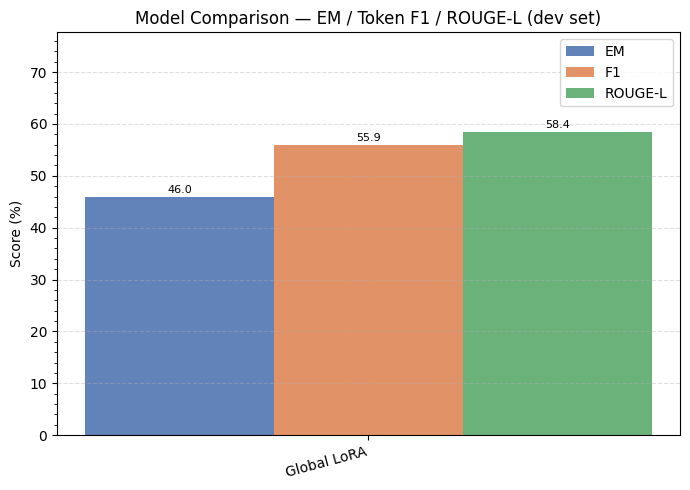

Saved -> /content/drive/MyDrive/chronicling_qa/viz_model_comparison.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Build rows from whatever metrics are available
_rows = []
if 'baseline_metrics' in globals():
    _rows.append({**baseline_metrics, 'model': 'Zero-shot'})
if 'global_lora_metrics' in globals():
    _rows.append({**global_lora_metrics, 'model': 'Global LoRA'})
for _b in ['early', 'mid', 'late']:
    _k = f'part_lora_{_b}'
    if _k in globals():
        _rows.append({**globals()[_k], 'model': f'LoRA-{_b.capitalize()}'})

if not _rows:
    print('No metrics found — run evaluation cells first.')
else:
    _metrics = ['EM', 'F1', 'ROUGE-L']
    _labels  = [r['model'] for r in _rows]
    _x       = np.arange(len(_labels))
    _width   = 0.25
    _colors  = ['#4C72B0', '#DD8452', '#55A868']

    fig, ax = plt.subplots(figsize=(max(7, len(_labels) * 1.6), 5))
    for j, (metric, color) in enumerate(zip(_metrics, _colors)):
        vals = [r.get(metric, 0) for r in _rows]
        bars = ax.bar(_x + (j - 1) * _width, vals, _width, label=metric, color=color, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, rotation=15, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title('Model Comparison — EM / Token F1 / ROUGE-L (dev set)')
    ax.legend(loc='upper right')
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.set_ylim(0, max(r.get('F1', 0) for r in _rows) * 1.3 + 5)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / 'viz_model_comparison.png', dpi=150)
    plt.show()
    print(f'Saved -> {OUTPUT_DIR}/viz_model_comparison.png')


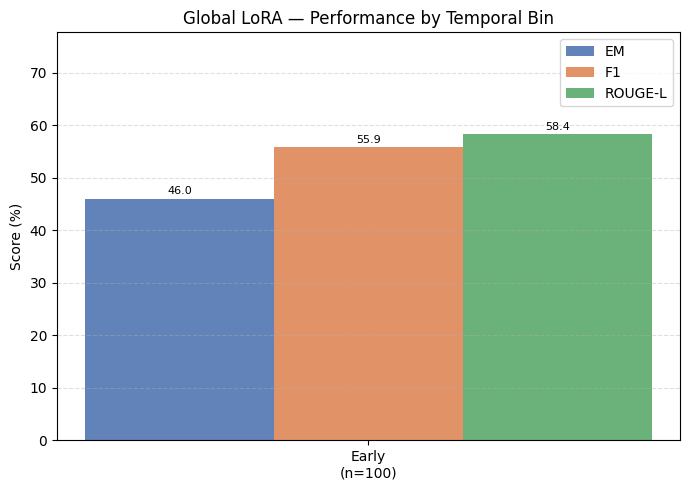

Saved -> /content/drive/MyDrive/chronicling_qa/viz_global_lora_per_bin.png


In [24]:
# Per-time-bin breakdown of global LoRA predictions
# Requires gl_preds, gl_golds, gl_bins from cell 29 / cell 33

if not all(v in globals() for v in ['gl_preds', 'gl_golds', 'gl_bins']):
    print('gl_preds / gl_golds / gl_bins not found — run the global LoRA eval cell first.')
else:
    _bin_order  = ['early', 'mid', 'late', 'unknown']
    _colors     = ['#4C72B0', '#DD8452', '#55A868']
    _bin_mets   = {}
    for _b in _bin_order:
        _idx = [i for i, x in enumerate(gl_bins) if x == _b]
        if not _idx:
            continue
        _bin_mets[_b] = compute_metrics([gl_preds[i] for i in _idx],
                                         [gl_golds[i] for i in _idx], label=_b)

    _present = [b for b in _bin_order if b in _bin_mets]
    _x = np.arange(len(_present))
    _w = 0.25
    fig, ax = plt.subplots(figsize=(7, 5))
    for j, metric in enumerate(['EM', 'F1', 'ROUGE-L']):
        vals = [_bin_mets[b][metric] for b in _present]
        bars = ax.bar(_x + (j - 1) * _w, vals, _w, label=metric,
                      color=_colors[j], alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(_x)
    ax.set_xticklabels([f"{b.capitalize()}\n(n={_bin_mets[b]['n']})" for b in _present])
    ax.set_ylabel('Score (%)')
    ax.set_title('Global LoRA — Performance by Temporal Bin')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(_bin_mets[b]['F1'] for b in _present) * 1.3 + 5)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / 'viz_global_lora_per_bin.png', dpi=150)
    plt.show()
    print(f'Saved -> {OUTPUT_DIR}/viz_global_lora_per_bin.png')


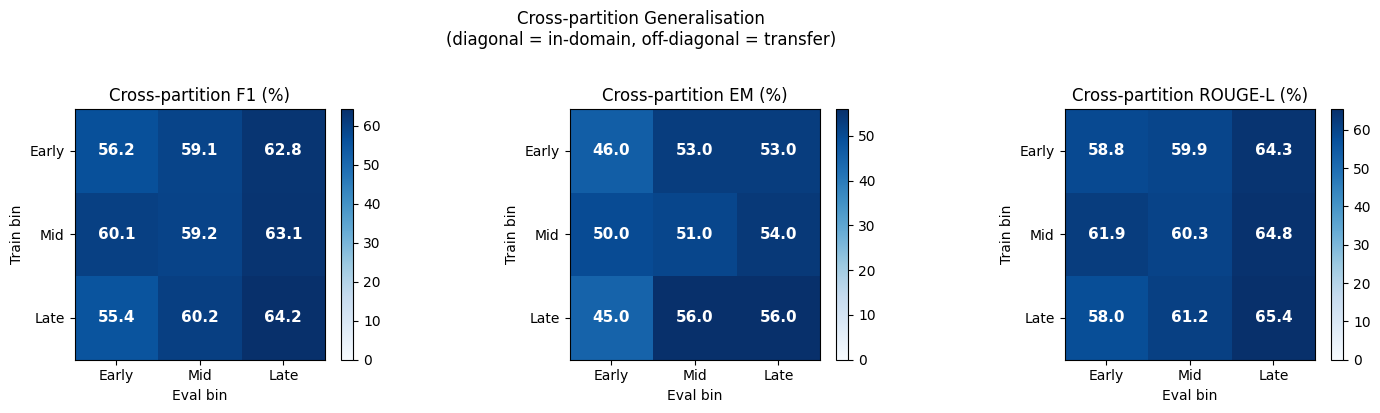

Saved -> /content/drive/MyDrive/chronicling_qa/viz_cross_partition_heatmap.png


In [25]:
# Cross-partition heatmap — requires cross_results from cell 35

if 'cross_results' not in globals() or not cross_results:
    print('cross_results not found — run cell 35 first.')
else:
    _bin_order = ['early', 'mid', 'late']
    _mlist     = ['F1', 'EM', 'ROUGE-L']

    fig, axes = plt.subplots(1, len(_mlist), figsize=(5 * len(_mlist), 4))
    for ax, metric in zip(axes, _mlist):
        _mat = np.full((len(_bin_order), len(_bin_order)), np.nan)
        for ri, tb in enumerate(_bin_order):
            for ci, eb in enumerate(_bin_order):
                if (tb, eb) in cross_results:
                    _mat[ri, ci] = cross_results[(tb, eb)][metric]

        _vmax = float(np.nanmax(_mat)) if not np.all(np.isnan(_mat)) else 1.0
        im = ax.imshow(_mat, cmap='Blues', vmin=0, vmax=_vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(_bin_order)))
        ax.set_yticks(range(len(_bin_order)))
        ax.set_xticklabels([b.capitalize() for b in _bin_order])
        ax.set_yticklabels([b.capitalize() for b in _bin_order])
        ax.set_xlabel('Eval bin')
        ax.set_ylabel('Train bin')
        ax.set_title(f'Cross-partition {metric} (%)')
        for ri in range(len(_bin_order)):
            for ci in range(len(_bin_order)):
                if not np.isnan(_mat[ri, ci]):
                    tc = 'white' if _mat[ri, ci] > _vmax * 0.6 else 'black'
                    ax.text(ci, ri, f'{_mat[ri, ci]:.1f}',
                            ha='center', va='center', fontsize=11,
                            color=tc, fontweight='bold')

    fig.suptitle('Cross-partition Generalisation\n(diagonal = in-domain, off-diagonal = transfer)',
                 fontsize=12, y=1.02)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / 'viz_cross_partition_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {OUTPUT_DIR}/viz_cross_partition_heatmap.png')


---
## Section 17 — Dataset & Preprocessing Visualisations

Charts covering split sizes, temporal bin distribution, answer/context length stats, and bin boundaries.

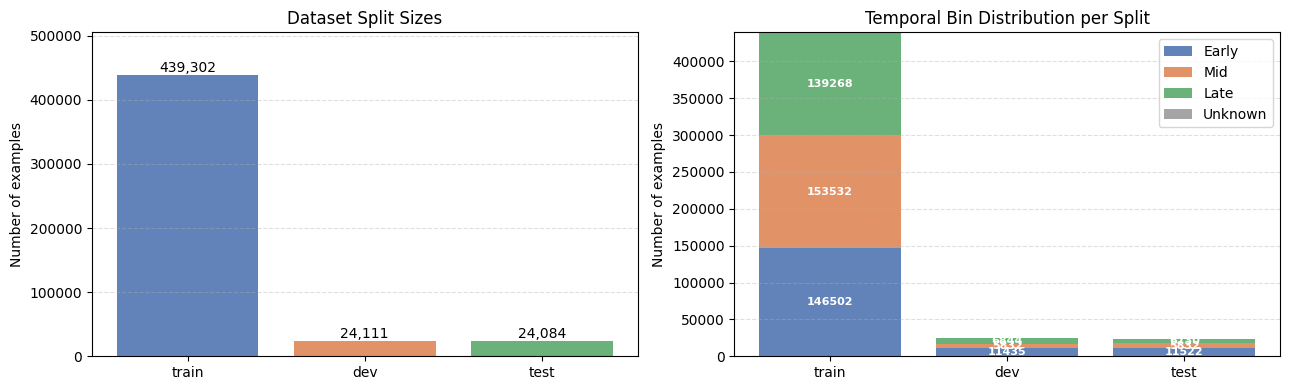

Saved -> /content/drive/MyDrive/chronicling_qa/viz_dataset_splits.png


In [32]:
# Split sizes and temporal bin distribution
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

_splits = {'train': train_binned, 'dev': dev_binned, 'test': test_binned}
_bin_order  = ['early', 'mid', 'late', 'unknown']
_bin_colors = ['#4C72B0', '#DD8452', '#55A868', '#999999']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: total samples per split
ax = axes[0]
_names = list(_splits.keys())
_sizes = [len(ds) for ds in _splits.values()]
bars = ax.bar(_names, _sizes, color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.88)
for bar, v in zip(bars, _sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Dataset Split Sizes')
ax.set_ylabel('Number of examples')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, max(_sizes) * 1.15)

# Right: stacked bar of bin counts per split
ax = axes[1]
_x = np.arange(len(_names))
_bottom = np.zeros(len(_names))
for _b, _c in zip(_bin_order, _bin_colors):
    _vals = [Counter(ds['time_bin']).get(_b, 0) for ds in _splits.values()]
    ax.bar(_x, _vals, bottom=_bottom, label=_b.capitalize(), color=_c, alpha=0.88)
    for xi, (v, bot) in enumerate(zip(_vals, _bottom)):
        if v > 0:
            ax.text(xi, bot + v / 2, str(v), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    _bottom += np.array(_vals, dtype=float)
ax.set_xticks(_x)
ax.set_xticklabels(_names)
ax.set_title('Temporal Bin Distribution per Split')
ax.set_ylabel('Number of examples')
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_dataset_splits.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_dataset_splits.png')


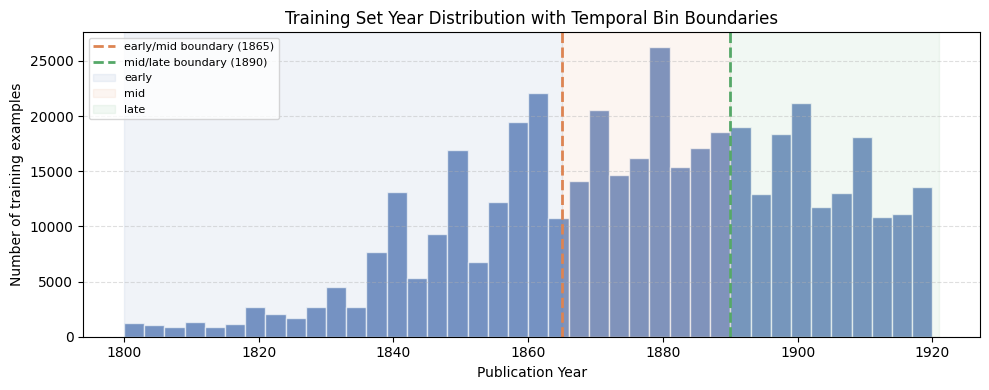

Saved -> /content/drive/MyDrive/chronicling_qa/viz_year_distribution.png


In [33]:
# Year distribution of training data with temporal bin boundaries
import matplotlib.pyplot as plt

_years = [extract_year(ex) for ex in train_binned]
_years = [y for y in _years if y > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_years, bins=40, color='#4C72B0', alpha=0.75, edgecolor='white')
ax.axvline(EARLY_MAX, color='#DD8452', linewidth=2, linestyle='--',
           label=f'early/mid boundary ({EARLY_MAX})')
ax.axvline(MID_MAX,   color='#55A868', linewidth=2, linestyle='--',
           label=f'mid/late boundary ({MID_MAX})')

# Shade regions
_ymax = ax.get_ylim()[1]
ax.axvspan(min(_years), EARLY_MAX, alpha=0.08, color='#4C72B0', label='early')
ax.axvspan(EARLY_MAX,   MID_MAX,   alpha=0.08, color='#DD8452', label='mid')
ax.axvspan(MID_MAX,     max(_years)+1, alpha=0.08, color='#55A868', label='late')

ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of training examples')
ax.set_title('Training Set Year Distribution with Temporal Bin Boundaries')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_year_distribution.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_year_distribution.png')


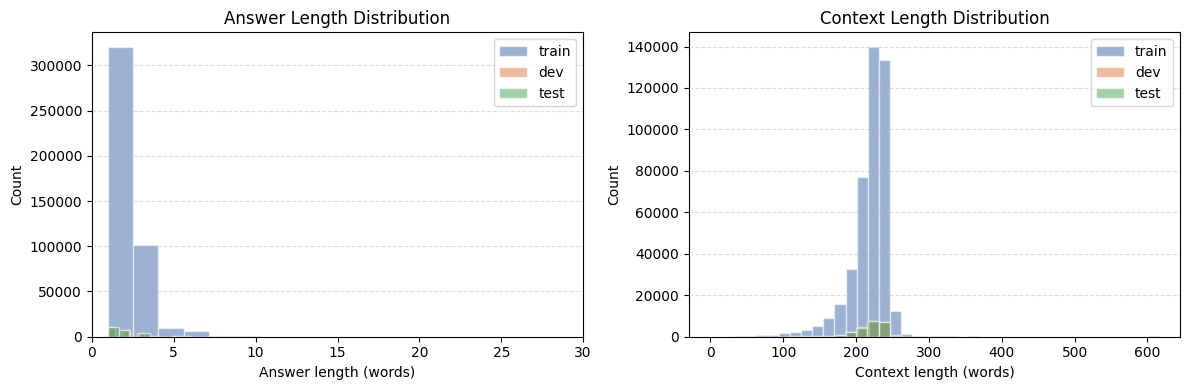

Saved -> /content/drive/MyDrive/chronicling_qa/viz_length_distributions.png


In [34]:
# Answer length and context length distributions across splits
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_split_styles = [
    ('train', train_binned, '#4C72B0'),
    ('dev',   dev_binned,   '#DD8452'),
    ('test',  test_binned,  '#55A868'),
]

# Answer lengths
ax = axes[0]
for name, ds, color in _split_styles:
    _lens = [len(str(ex.get('answer', '')).split()) for ex in ds]
    ax.hist(_lens, bins=30, alpha=0.55, color=color, label=name, edgecolor='white')
ax.set_xlabel('Answer length (words)')
ax.set_ylabel('Count')
ax.set_title('Answer Length Distribution')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0, 30)

# Context lengths
ax = axes[1]
for name, ds, color in _split_styles:
    _lens = [len(str(ex.get('context', '')).split()) for ex in ds]
    ax.hist(_lens, bins=40, alpha=0.55, color=color, label=name, edgecolor='white')
ax.set_xlabel('Context length (words)')
ax.set_ylabel('Count')
ax.set_title('Context Length Distribution')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_length_distributions.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_length_distributions.png')


---
## Section 18 — Training Dynamics & Verbosity Analysis

1. Eval loss curve over training epochs
2. Predicted vs gold answer length — direct evidence of the verbosity fix

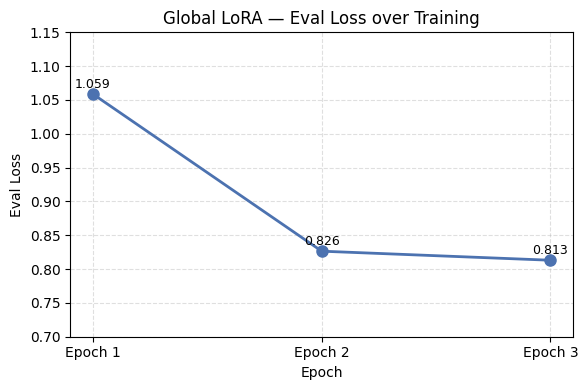

Saved -> /content/drive/MyDrive/chronicling_qa/viz_eval_loss_curve.png


In [35]:
# Eval loss curve over training
import matplotlib.pyplot as plt

# Logged eval_loss values from training output
_epochs     = [1.0, 2.0, 3.0]
_eval_loss  = [1.058652, 0.826455, 0.813076]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(_epochs, _eval_loss, marker='o', color='#4C72B0', linewidth=2, markersize=8)
for x, y in zip(_epochs, _eval_loss):
    ax.text(x, y + 0.005, f'{y:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Epoch')
ax.set_ylabel('Eval Loss')
ax.set_title('Global LoRA — Eval Loss over Training')
ax.set_xticks(_epochs)
ax.set_xticklabels([f'Epoch {int(e)}' for e in _epochs])
ax.grid(linestyle='--', alpha=0.4)
ax.set_ylim(0.7, 1.15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_eval_loss_curve.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_eval_loss_curve.png')


Mean answer lengths:
  Gold answer  : 2.0 words
  Zero-shot    : 11.3 words
  Global LoRA  : 1.9 words


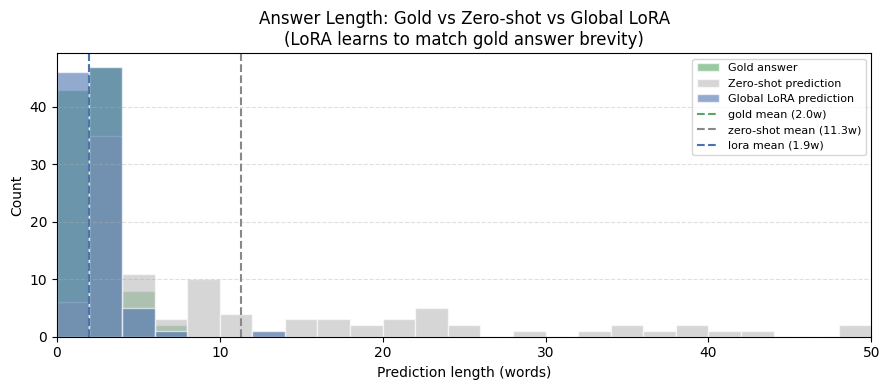

Saved -> /content/drive/MyDrive/chronicling_qa/viz_answer_length_comparison.png


In [36]:
# Predicted vs gold answer length — shows verbosity fix
# Loads from saved CSVs on Drive
import matplotlib.pyplot as plt
import pandas as pd

_baseline_csv    = OUTPUT_DIR / 'dev_predictions_baseline.csv'
_global_lora_csv = OUTPUT_DIR / 'dev_predictions_global_lora.csv'

if not _baseline_csv.exists() or not _global_lora_csv.exists():
    print(f'Missing CSVs — need both:\n  {_baseline_csv}\n  {_global_lora_csv}')
else:
    _df_base = pd.read_csv(_baseline_csv)
    _df_lora = pd.read_csv(_global_lora_csv)

    _gold_lens = [len(str(a).split()) for a in _df_lora['gold_answer']]
    _base_lens = [len(str(p).split()) for p in _df_base['prediction']]
    _lora_lens = [len(str(p).split()) for p in _df_lora['prediction']]

    print(f'Mean answer lengths:')
    print(f'  Gold answer  : {sum(_gold_lens)/len(_gold_lens):.1f} words')
    print(f'  Zero-shot    : {sum(_base_lens)/len(_base_lens):.1f} words')
    print(f'  Global LoRA  : {sum(_lora_lens)/len(_lora_lens):.1f} words')

    fig, ax = plt.subplots(figsize=(9, 4))
    _bins = range(0, 51, 2)
    ax.hist(_gold_lens, bins=_bins, alpha=0.6, color='#55A868', label='Gold answer', edgecolor='white')
    ax.hist(_base_lens, bins=_bins, alpha=0.6, color='#bbbbbb', label='Zero-shot prediction', edgecolor='white')
    ax.hist(_lora_lens, bins=_bins, alpha=0.6, color='#4C72B0', label='Global LoRA prediction', edgecolor='white')

    for vals, color, label in [
        (_gold_lens, '#55A868', 'gold'),
        (_base_lens, '#888888', 'zero-shot'),
        (_lora_lens, '#4C72B0', 'lora'),
    ]:
        _mean = sum(vals) / len(vals)
        ax.axvline(_mean, color=color, linestyle='--', linewidth=1.5,
                   label=f'{label} mean ({_mean:.1f}w)')

    ax.set_xlabel('Prediction length (words)')
    ax.set_ylabel('Count')
    ax.set_title('Answer Length: Gold vs Zero-shot vs Global LoRA\n(LoRA learns to match gold answer brevity)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 50)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / 'viz_answer_length_comparison.png', dpi=150)
    plt.show()
    print(f'Saved -> {OUTPUT_DIR}/viz_answer_length_comparison.png')


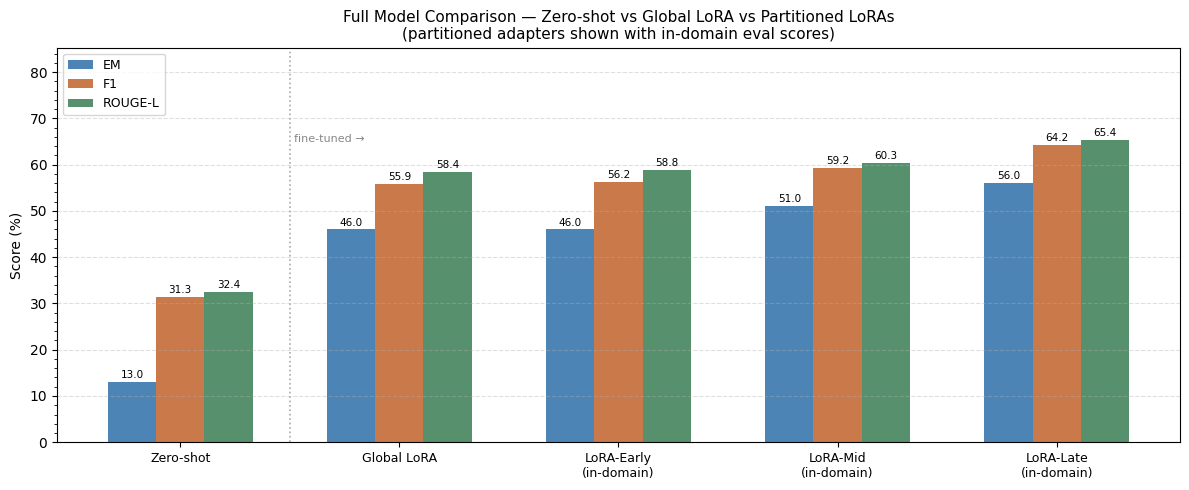

Saved -> /content/drive/MyDrive/chronicling_qa/viz_full_model_comparison.png


In [48]:
# Full comparison: zero-shot vs global LoRA vs partitioned LoRAs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── All results hardcoded — avoids session state issues ───────────────────
_baseline     = {'EM': 13.0,  'F1': 31.34, 'ROUGE-L': 32.44}
_global_lora  = {'EM': 46.0,  'F1': 55.9,  'ROUGE-L': 58.38}
_lora_early   = {'EM': 46.0,  'F1': 56.2,  'ROUGE-L': 58.8}
_lora_mid     = {'EM': 51.0,  'F1': 59.2,  'ROUGE-L': 60.3}
_lora_late    = {'EM': 56.0,  'F1': 64.2,  'ROUGE-L': 65.4}

_rows = [
    {'label': 'Zero-shot',           'color': '#bbbbbb', **_baseline},
    {'label': 'Global LoRA',          'color': '#4C72B0', **_global_lora},
    {'label': 'LoRA-Early\n(in-domain)', 'color': '#5BA8D4', **_lora_early},
    {'label': 'LoRA-Mid\n(in-domain)',   'color': '#DD8452', **_lora_mid},
    {'label': 'LoRA-Late\n(in-domain)',  'color': '#55A868', **_lora_late},
]
_metrics = ['EM', 'F1', 'ROUGE-L']
_x       = np.arange(len(_rows))
_w       = 0.22
_mcolors = ['#2d6fa8', '#c0622a', '#3a7d52']

fig, ax = plt.subplots(figsize=(12, 5))
for j, (metric, mc) in enumerate(zip(_metrics, _mcolors)):
    vals = [r.get(metric, 0) for r in _rows]
    bars = ax.bar(_x + (j - 1) * _w, vals, _w, label=metric, color=mc, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.axvline(0.5, color='#aaaaaa', linestyle=':', linewidth=1.2)
ax.text(0.52, ax.get_ylim()[1] * 0.97, 'fine-tuned →',
        ha='left', va='top', fontsize=8, color='#888888')
ax.set_xticks(_x)
ax.set_xticklabels([r['label'] for r in _rows], fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Full Model Comparison — Zero-shot vs Global LoRA vs Partitioned LoRAs\n'
             '(partitioned adapters shown with in-domain eval scores)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.set_ylim(0, max(r.get('F1', 0) for r in _rows) * 1.25 + 5)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_full_model_comparison.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_full_model_comparison.png')



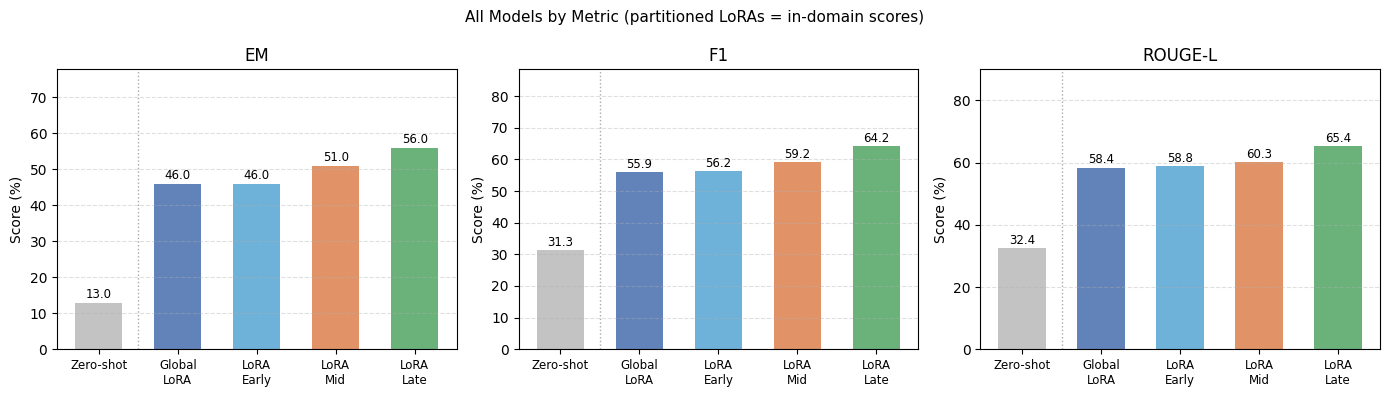

Saved -> /content/drive/MyDrive/chronicling_qa/viz_per_metric_comparison.png


In [50]:
# Per-metric subplot — one panel per metric, all models side by side
import matplotlib.pyplot as plt
import numpy as np

# ── All results hardcoded — avoids session state issues ───────────────────
_baseline    = {'EM': 13.0,  'F1': 31.34, 'ROUGE-L': 32.44}
_global_lora = {'EM': 46.0,  'F1': 55.9,  'ROUGE-L': 58.38}
_lora_early  = {'EM': 46.0,  'F1': 56.2,  'ROUGE-L': 58.8}
_lora_mid    = {'EM': 51.0,  'F1': 59.2,  'ROUGE-L': 60.3}
_lora_late   = {'EM': 56.0,  'F1': 64.2,  'ROUGE-L': 65.4}

_model_labels  = ['Zero-shot', 'Global\nLoRA', 'LoRA\nEarly', 'LoRA\nMid', 'LoRA\nLate']
_model_colors  = ['#bbbbbb', '#4C72B0', '#5BA8D4', '#DD8452', '#55A868']
_metrics       = ['EM', 'F1', 'ROUGE-L']
_all_scores    = {
    'EM':      [_baseline['EM'],     _global_lora['EM'],     _lora_early['EM'],     _lora_mid['EM'],     _lora_late['EM']],
    'F1':      [_baseline['F1'],     _global_lora['F1'],     _lora_early['F1'],     _lora_mid['F1'],     _lora_late['F1']],
    'ROUGE-L': [_baseline['ROUGE-L'],_global_lora['ROUGE-L'],_lora_early['ROUGE-L'],_lora_mid['ROUGE-L'],_lora_late['ROUGE-L']],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, metric in zip(axes, _metrics):
    vals = _all_scores[metric]
    bars = ax.bar(range(len(vals)), vals, color=_model_colors, alpha=0.88, width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(_model_labels, fontsize=8.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, max(vals) * 1.3 + 5)
    ax.axvline(0.5, color='#aaaaaa', linestyle=':', linewidth=1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('All Models by Metric (partitioned LoRAs = in-domain scores)', fontsize=11)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_per_metric_comparison.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_per_metric_comparison.png')


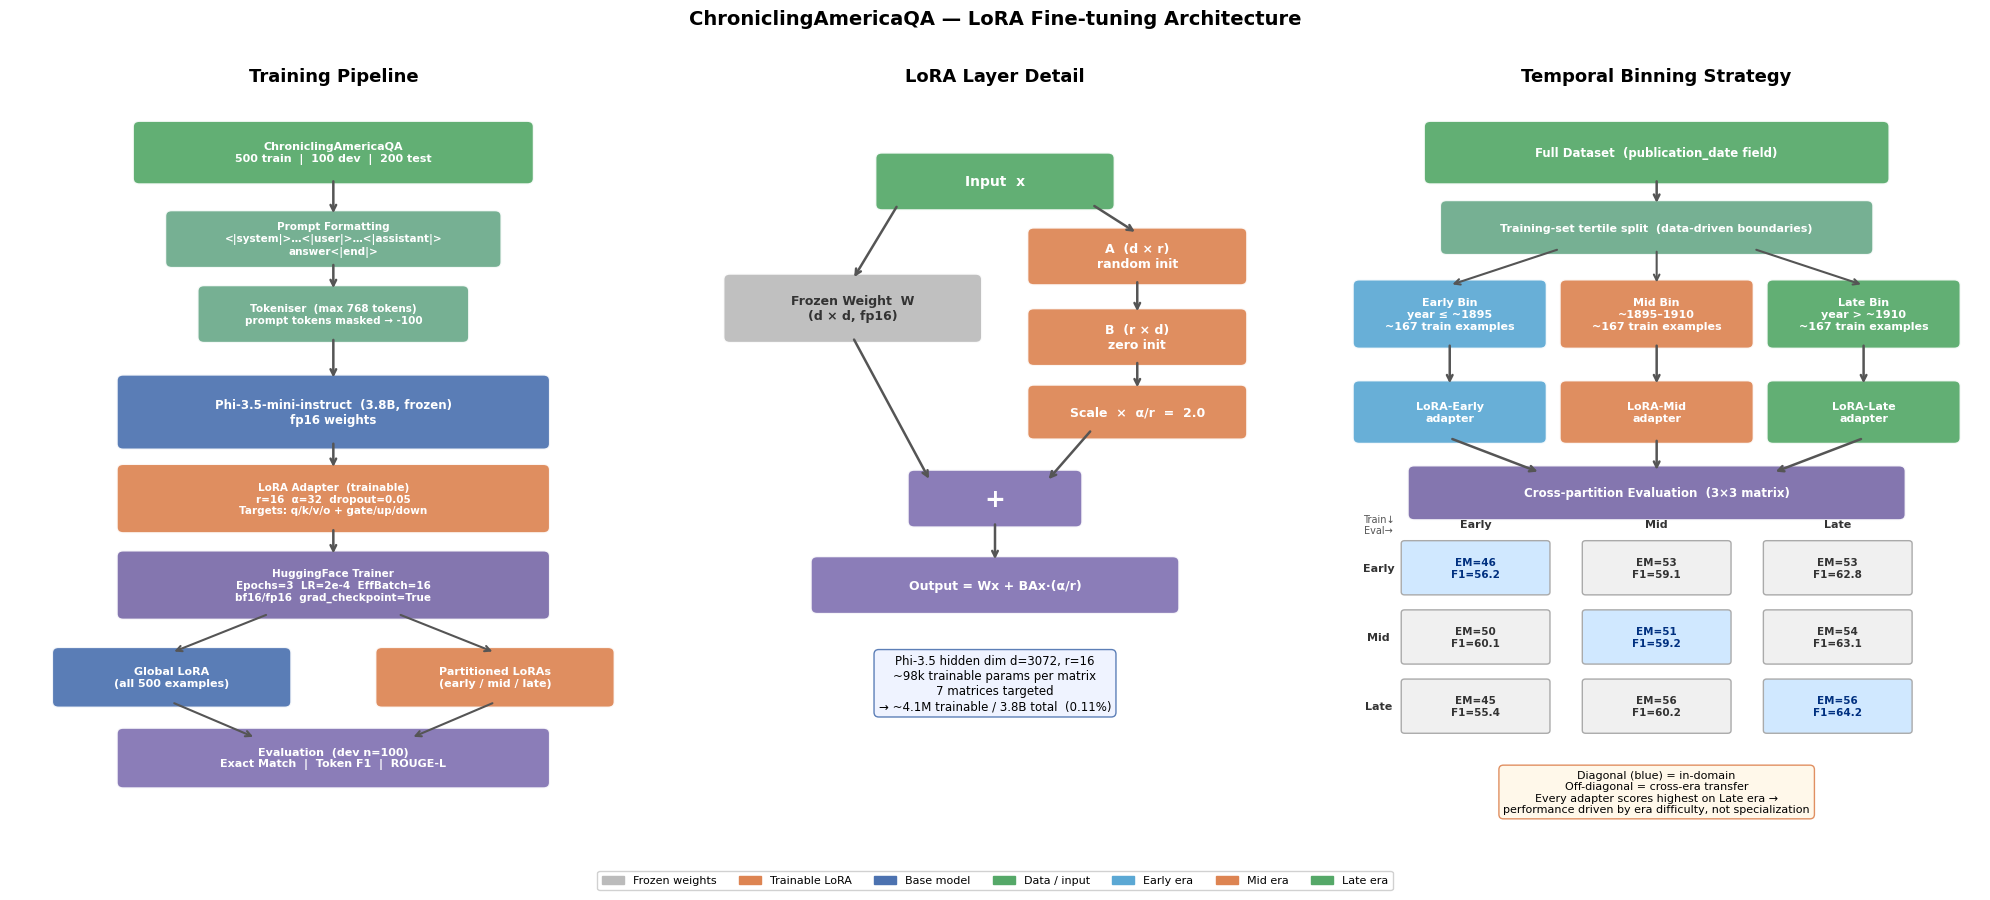

Saved -> /content/drive/MyDrive/chronicling_qa/viz_architecture.png


In [52]:
# Architecture diagram — training pipeline + LoRA detail + temporal binning
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 3, figsize=(20, 9))

C_BASE   = '#4C72B0'
C_LORA   = '#DD8452'
C_DATA   = '#55A868'
C_OUT    = '#8172B2'
C_FROZEN = '#bbbbbb'
C_EARLY  = '#5BA8D4'
C_MID    = '#DD8452'
C_LATE   = '#55A868'
C_BG     = '#f8f8f8'

def box(ax, x, y, w, h, color, text, fontsize=9, text_color='white', alpha=0.92):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
                                boxstyle='round,pad=0.1', facecolor=color,
                                edgecolor='white', linewidth=1.5, alpha=alpha))
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='#555555', label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        ax.text((x1+x2)/2+0.15, (y1+y2)/2, label, fontsize=7, color=color)

# ══════════════════════════════════════════════════════════════════
# PANEL 1 — Training Pipeline
# ══════════════════════════════════════════════════════════════════
ax = axes[0]
ax.set_xlim(0,10); ax.set_ylim(0,13); ax.set_facecolor(C_BG); ax.axis('off')
ax.set_title('Training Pipeline', fontsize=13, fontweight='bold', pad=10)

box(ax, 5, 12,   6,   0.9, C_DATA,    'ChroniclingAmericaQA\n500 train  |  100 dev  |  200 test', 8)
box(ax, 5, 10.5, 5,   0.8, '#6aaa8a', 'Prompt Formatting\n<|system|>…<|user|>…<|assistant|>\nanswer<|end|>', 7.5)
arrow(ax, 5, 11.55, 5, 10.9)
box(ax, 5, 9.2,  4,   0.8, '#6aaa8a', 'Tokeniser  (max 768 tokens)\nprompt tokens masked → -100', 7.5)
arrow(ax, 5, 10.1, 5, 9.6)
box(ax, 5, 7.5,  6.5, 1.1, C_BASE,   'Phi-3.5-mini-instruct  (3.8B, frozen)\nfp16 weights', 8.5)
arrow(ax, 5, 8.8,  5, 8.05)
box(ax, 5, 6.0,  6.5, 1.0, C_LORA,   'LoRA Adapter  (trainable)\nr=16  α=32  dropout=0.05\nTargets: q/k/v/o + gate/up/down', 7.5)
arrow(ax, 5, 7.0,  5, 6.5)
box(ax, 5, 4.5,  6.5, 1.0, '#7a6aa8', 'HuggingFace Trainer\nEpochs=3  LR=2e-4  EffBatch=16\nbf16/fp16  grad_checkpoint=True', 7.5)
arrow(ax, 5, 5.5,  5, 5.0)
box(ax, 2.5, 2.9, 3.5, 0.85, C_BASE,  'Global LoRA\n(all 500 examples)', 8)
box(ax, 7.5, 2.9, 3.5, 0.85, C_LORA,  'Partitioned LoRAs\n(early / mid / late)', 8)
ax.annotate('', xy=(2.5,3.33), xytext=(4.0,4.0), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
ax.annotate('', xy=(7.5,3.33), xytext=(6.0,4.0), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
box(ax, 5, 1.5,  6.5, 0.85, C_OUT,   'Evaluation  (dev n=100)\nExact Match  |  Token F1  |  ROUGE-L', 8)
ax.annotate('', xy=(3.8,1.85), xytext=(2.5,2.47), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
ax.annotate('', xy=(6.2,1.85), xytext=(7.5,2.47), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))

# ══════════════════════════════════════════════════════════════════
# PANEL 2 — LoRA Layer Detail
# ══════════════════════════════════════════════════════════════════
ax2 = axes[1]
ax2.set_xlim(0,10); ax2.set_ylim(0,13); ax2.set_facecolor(C_BG); ax2.axis('off')
ax2.set_title('LoRA Layer Detail', fontsize=13, fontweight='bold', pad=10)

box(ax2, 5, 11.5, 3.5, 0.8, C_DATA,   'Input  x', 10)
box(ax2, 2.8, 9.3, 3.8, 1.0, C_FROZEN,'Frozen Weight  W\n(d × d, fp16)', 9, '#333')
arrow(ax2, 3.5, 11.1, 2.8, 9.8)
box(ax2, 7.2, 10.2, 3.2, 0.8, C_LORA, 'A  (d × r)\nrandom init', 9)
box(ax2, 7.2, 8.8,  3.2, 0.8, C_LORA, 'B  (r × d)\nzero init', 9)
arrow(ax2, 6.5, 11.1, 7.2, 10.6)
arrow(ax2, 7.2, 9.8,  7.2, 9.2)
box(ax2, 7.2, 7.5,  3.2, 0.75, C_LORA,'Scale  ×  α/r  =  2.0', 9)
arrow(ax2, 7.2, 8.4,  7.2, 7.88)
box(ax2, 5, 6.0,   2.5, 0.8, '#8172B2','+', 18)
arrow(ax2, 2.8, 8.8, 4.0, 6.3)
arrow(ax2, 6.5, 7.2, 5.8, 6.3)
box(ax2, 5, 4.5,   5.5, 0.8, C_OUT,   'Output = Wx + BAx·(α/r)', 9)
arrow(ax2, 5, 5.6,  5, 4.9)
ax2.text(5, 3.3,
         'Phi-3.5 hidden dim d=3072, r=16\n'
         '~98k trainable params per matrix\n'
         '7 matrices targeted\n'
         '→ ~4.1M trainable / 3.8B total  (0.11%)',
         ha='center', va='top', fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#eef2ff', edgecolor=C_BASE, alpha=0.9))

# ══════════════════════════════════════════════════════════════════
# PANEL 3 — Temporal Binning
# ══════════════════════════════════════════════════════════════════
ax3 = axes[2]
ax3.set_xlim(0,10); ax3.set_ylim(0,13); ax3.set_facecolor(C_BG); ax3.axis('off')
ax3.set_title('Temporal Binning Strategy', fontsize=13, fontweight='bold', pad=10)

# Full dataset
box(ax3, 5, 12, 7, 0.9, C_DATA, 'Full Dataset  (publication_date field)', 8.5)

# Tertile split
box(ax3, 5, 10.7, 6.5, 0.75, '#6aaa8a',
    'Training-set tertile split  (data-driven boundaries)', 8)
arrow(ax3, 5, 11.55, 5, 11.08)

# Three bin boxes
box(ax3, 1.8, 9.2, 2.8, 1.0, C_EARLY, 'Early Bin\nyear ≤ ~1895\n~167 train examples', 8)
box(ax3, 5.0, 9.2, 2.8, 1.0, C_MID,   'Mid Bin\n~1895–1910\n~167 train examples', 8)
box(ax3, 8.2, 9.2, 2.8, 1.0, C_LATE,  'Late Bin\nyear > ~1910\n~167 train examples', 8)
ax3.annotate('', xy=(1.8,9.7),  xytext=(3.5,10.33), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
ax3.annotate('', xy=(5.0,9.7),  xytext=(5.0,10.33), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
ax3.annotate('', xy=(8.2,9.7),  xytext=(6.5,10.33), arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))

# Three adapters
box(ax3, 1.8, 7.5, 2.8, 0.9, C_EARLY, 'LoRA-Early\nadapter', 8)
box(ax3, 5.0, 7.5, 2.8, 0.9, C_MID,   'LoRA-Mid\nadapter', 8)
box(ax3, 8.2, 7.5, 2.8, 0.9, C_LATE,  'LoRA-Late\nadapter', 8)
arrow(ax3, 1.8, 8.7, 1.8, 7.95)
arrow(ax3, 5.0, 8.7, 5.0, 7.95)
arrow(ax3, 8.2, 8.7, 8.2, 7.95)

# Cross-partition eval grid
box(ax3, 5, 6.1, 7.5, 0.75, '#7a6aa8',
    'Cross-partition Evaluation  (3×3 matrix)', 8.5)
arrow(ax3, 1.8, 7.05, 3.2, 6.45)
arrow(ax3, 5.0, 7.05, 5.0, 6.45)
arrow(ax3, 8.2, 7.05, 6.8, 6.45)

# Grid cells
_bins  = ['Early', 'Mid', 'Late']
_xs    = [2.2, 5.0, 7.8]
_ys    = [4.8, 3.6, 2.4]
_em    = [[46,53,53],[50,51,54],[45,56,56]]
_f1    = [[56.2,59.1,62.8],[60.1,59.2,63.1],[55.4,60.2,64.2]]
ax3.text(0.7, 5.55, 'Train↓\nEval→', ha='center', va='center', fontsize=7, color='#555')
for ci, (bx, bl) in enumerate(zip(_xs, _bins)):
    ax3.text(bx, 5.55, bl, ha='center', va='center', fontsize=8, fontweight='bold', color='#333')
for ri, (ry, rl) in enumerate(zip(_ys, _bins)):
    ax3.text(0.7, ry, rl, ha='center', va='center', fontsize=8, fontweight='bold', color='#333')
    for ci, bx in enumerate(_xs):
        _is_diag = (ri == ci)
        _color   = '#d0e8ff' if _is_diag else '#f0f0f0'
        _tc      = '#003080' if _is_diag else '#333333'
        ax3.add_patch(FancyBboxPatch((bx-1.1, ry-0.42), 2.2, 0.84,
                                     boxstyle='round,pad=0.05',
                                     facecolor=_color, edgecolor='#aaaaaa', linewidth=1))
        ax3.text(bx, ry, f'EM={_em[ri][ci]}\nF1={_f1[ri][ci]}',
                 ha='center', va='center', fontsize=7.5, color=_tc, fontweight='bold')

ax3.text(5, 1.3,
         'Diagonal (blue) = in-domain\nOff-diagonal = cross-era transfer\n'
         'Every adapter scores highest on Late era →\nperformance driven by era difficulty, not specialization',
         ha='center', va='top', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8e8', edgecolor='#DD8452', alpha=0.9))

# ── Legend ────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color=C_FROZEN, label='Frozen weights'),
    mpatches.Patch(color=C_LORA,   label='Trainable LoRA'),
    mpatches.Patch(color=C_BASE,   label='Base model'),
    mpatches.Patch(color=C_DATA,   label='Data / input'),
    mpatches.Patch(color=C_EARLY,  label='Early era'),
    mpatches.Patch(color=C_MID,    label='Mid era'),
    mpatches.Patch(color=C_LATE,   label='Late era'),
]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, 0.005), framealpha=0.9, edgecolor='#cccccc')

fig.suptitle('ChroniclingAmericaQA — LoRA Fine-tuning Architecture',
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0.045, 1, 0.98])
plt.savefig(OUTPUT_DIR / 'viz_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_DIR}/viz_architecture.png')
